In [3]:
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem import Draw
from rdkit.Chem.Draw import IPythonConsole
IPythonConsole.molSize = 250,250
IPythonConsole.ipython_useSVG=False  # PNG切换SVG开关

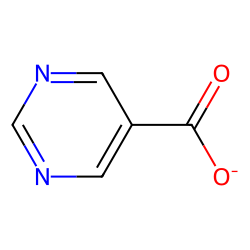

In [4]:
# Gasteiger-Marsili方法迭代计算原子的部分电荷
m = Chem.MolFromSmiles('c1ncncc1C(=O)[O-]')
AllChem.ComputeGasteigerCharges(m)
m

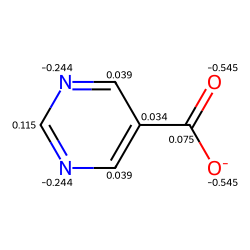

In [5]:
# 遍历原子显示计算出的部分电荷
m2 = Chem.Mol(m)
for at in m2.GetAtoms():
    lbl = '%.3f'%(at.GetDoubleProp("_GasteigerCharge"))
    at.SetProp('atomNote',lbl)
m2

0 SP3
1 SP2
2 SP2
3 SP2
4 SP2
5 SP2
6 SP2
7 SP2
8 SP2
9 SP2
10 SP2
11 SP2
12 SP3
13 SP3


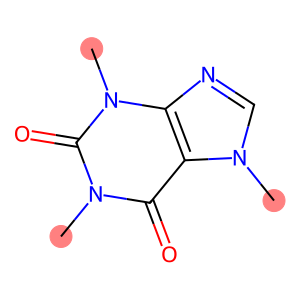

In [6]:
# 碳原子的轨道杂化，可以联合画图给高亮出来

m = Chem.MolFromSmiles("CN1C=NC2=C1C(=O)N(C(=O)N2C)C")
SP3List =[]
for x in m.GetAtoms():
    print(x.GetIdx(), x.GetHybridization())
    if (x.GetHybridization() == Chem.HybridizationType.SP3): SP3List.append(x.GetIdx())

img = Draw.MolToImage(m, highlightAtoms=SP3List)
display(img)


[{1, 2, 4, 5, 6, 7, 8, 9, 10, 11, 12}, {14, 15, 16, 17, 18, 19}]


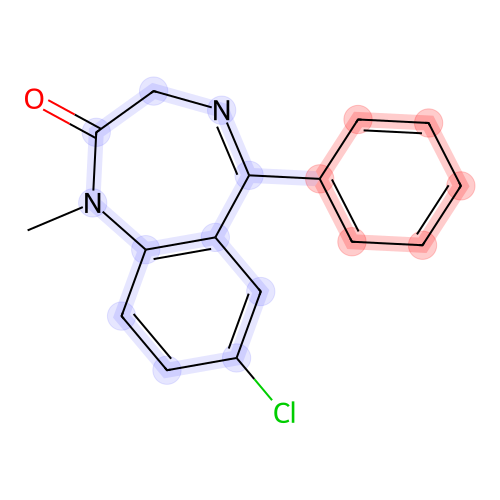

In [7]:
# 判断环和其原子构成
def GetRingSystems(mol, includeSpiro=False):
    ri = mol.GetRingInfo()
    systems = []
    for ring in ri.AtomRings():
        ringAts = set(ring)
        nSystems = []
        for system in systems:
            nInCommon = len(ringAts.intersection(system))
            if nInCommon and (includeSpiro or nInCommon>1):
                ringAts = ringAts.union(system)
            else:
                nSystems.append(system)
        nSystems.append(ringAts)
        systems = nSystems
    return systems
mol = Chem.MolFromSmiles('CN1C(=O)CN=C(C2=C1C=CC(=C2)Cl)C3=CC=CC=C3')
print(GetRingSystems(mol))

# 来都来了画个图吧
from rdkit.Chem.Draw import rdMolDraw2D
import io
from PIL import Image
def color_ring_systems(mol, systems, size=(500, 500)):
    colors = [(0.0, 0.0, 1.0, 0.1), (1.0, 0.0, 0.0, 0.2)]
    atom_colors = {}
    for i, system in enumerate(systems):
        color = colors[i % len(colors)]
        for atom_idx in system:
            atom_colors[atom_idx] = color
    
    highlight_atoms = list(atom_colors.keys())
    drawer = rdMolDraw2D.MolDraw2DCairo(size[0], size[1])

    opts = drawer.drawOptions()
    opts.addAtomIndices = False # 原子索引开关

    drawer.DrawMolecule(
        mol,
        highlightAtoms=highlight_atoms,
        highlightAtomColors=atom_colors
    )
    drawer.FinishDrawing()
    bio = io.BytesIO(drawer.GetDrawingText())
    return Image.open(bio)

color_ring_systems(mol,GetRingSystems(mol))

[(1, 'S'), (5, 'R'), (7, 'R')]


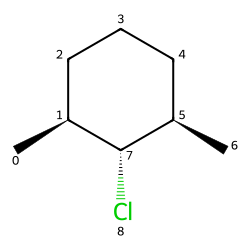

In [8]:
# 统计手性原子
IPythonConsole.drawOptions.addAtomIndices = True
m = Chem.MolFromSmiles("C[C@H]1CCC[C@@H](C)[C@@H]1Cl")
print(Chem.FindMolChiralCenters(m,force=True,includeUnassigned=True,useLegacyImplementation=True))
m

0 1 SINGLE STEREONONE
1 2 DOUBLE STEREOZ
2 3 SINGLE STEREONONE
2 4 SINGLE STEREONONE
4 5 DOUBLE STEREOE
5 6 SINGLE STEREONONE
4 7 SINGLE STEREONONE
7 8 DOUBLE STEREONONE


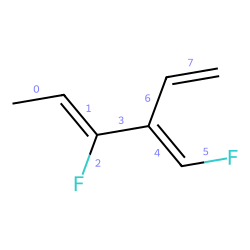

In [9]:
# 统计双键的顺反异构
IPythonConsole.drawOptions.addAtomIndices = False
IPythonConsole.drawOptions.addBondIndices = True

mol = Chem.MolFromSmiles(r"C\C=C(/F)\C(=C\F)\C=C")
for b in mol.GetBonds():
    print(b.GetBeginAtomIdx(),b.GetEndAtomIdx(),
          b.GetBondType(),b.GetStereo())
mol


['C[n+]1cc[nH]c1', 'CC[n+]1cc[nH]c1', 'CCC[n+]1cc[nH]c1', 'CCCC[n+]1cc[nH]c1', 'CCCCC[n+]1cc[nH]c1', 'CCCCCC[n+]1cc[nH]c1']


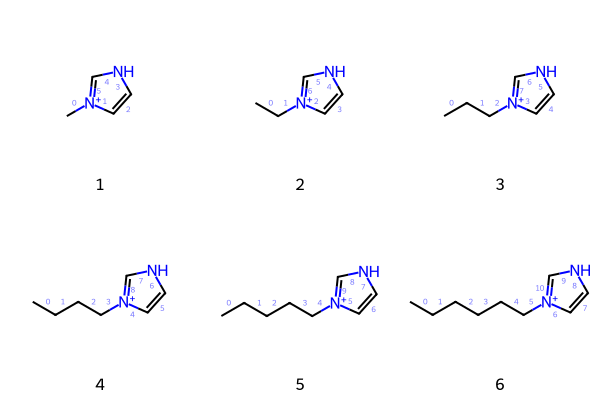

In [10]:
# 固定骨架+枚举侧链

core = Chem.MolFromSmiles('*[n+]1cc[nH]c1')
chains = ['C','CC','CCC','CCCC','CCCCC','CCCCCC']
chainMols = [Chem.MolFromSmiles(chain) for chain in chains]

product_smi = []
for chainMol in chainMols:
    product_mol = Chem.ReplaceSubstructs(core, Chem.MolFromSmarts('*'), chainMol)
    cleaned_mol = Chem.MolFromSmiles(Chem.MolToSmiles(product_mol[0]))
    product_smi.append(Chem.MolToSmiles(cleaned_mol))
print(product_smi)

from rdkit.Chem.Draw import rdDepictor
rdDepictor.SetPreferCoordGen(True) # 都给我站直了

mols = [Chem.MolFromSmiles(smi) for smi in product_smi]
img = Draw.MolsToGridImage(mols, molsPerRow=3, legends=[f"{i+1}" for i in range(len(mols))])
display(img)

In [11]:
# 枚举多位点连接
# 先从已有分子中分解出各连接位点的R基团
from itertools import product
import pandas as pd
from rdkit.Chem import rdRGroupDecomposition as rdRGD

rgroup_core = Chem.MolFromSmarts("c1cc([*:1])ccc1[*:2]") # 对位二取代苯作为骨架
seed_smiles = [
    "Cc1ccc(N)cc1",
    "CCOc1ccc(Cl)cc1",
    "O=C(O)c1ccc(OC)cc1",
]
seed_mols = [Chem.MolFromSmiles(smi) for smi in seed_smiles] # 骨架相同但取代基不同

params = rdRGD.RGroupDecompositionParameters()
params.labels = rdRGD.RGroupLabels.AtomMapLabels # 原子映射号作为标签
params.onlyMatchAtRGroups = True # 只匹配R基团

rgroup_rows, unmatched = rdRGD.RGroupDecompose(
    [rgroup_core], seed_mols, asSmiles=False, asRows=True, options=params
) # 每行一个分子，不以SMILES输出

if unmatched:
    raise ValueError(f"以下输入没有匹配骨架: {unmatched}")

decomposition_df = pd.DataFrame([
    {name: Chem.MolToSmiles(mol, canonical=True) for name, mol in row.items()}
    for row in rgroup_rows
]) # 转化为DataFrame
decomposition_df

,Core,R1,R2
0,c1cc([*:2])ccc1[*:1],N[*:1],C[*:2]
1,c1cc([*:2])ccc1[*:1],Cl[*:1],CCO[*:2]
2,c1cc([*:2])ccc1[*:1],CO[*:1],O=C(O)[*:2]


In [12]:
# 对 RGroupDecompose 的行结果做任意位点数的笛卡尔积枚举
def enumerate_rgroup_combinations(rows):
    if not rows:
        return [], {}

    labels = sorted(
        (name for name in rows[0] if name != "Core"),
        key=lambda name: int(name[1:]) if name[1:].isdigit() else name,
    ) # 提取非Core的列名
    core = Chem.Mol(rows[0]["Core"]) # 提取Core

    # 每个位点独立去重，保留带 [*:n] 的连接标签供 molzip 使用
    rgroup_pools = {}
    for label in labels:
        unique_fragments = {}
        for row in rows:
            fragment = row.get(label)
            if fragment is None:
                continue
            fragment_smiles = Chem.MolToSmiles(fragment, canonical=True)
            unique_fragments[fragment_smiles] = Chem.Mol(fragment)
        if not unique_fragments:
            raise ValueError(f"位点 {label} 没有可用于枚举的侧链")
        rgroup_pools[label] = unique_fragments

    # 笛卡尔积枚举
    records = []
    seen_products = set()
    pool_values = [list(rgroup_pools[label].items()) for label in labels]
    for choices in product(*pool_values):
        combined = Chem.Mol(core)
        selected = {}
        for label, (fragment_smiles, fragment) in zip(labels, choices):
            combined = Chem.CombineMols(combined, fragment)
            selected[label] = fragment_smiles

        # molzip连接虚拟原子位点
        product_mol = Chem.molzip(combined)
        Chem.SanitizeMol(product_mol)
        product_smiles = Chem.MolToSmiles(product_mol, canonical=True)
        # 再次去重
        if product_smiles in seen_products:
            continue
        seen_products.add(product_smiles)
        records.append({**selected, "SMILES": product_smiles, "Mol": product_mol})

    return records, rgroup_pools

各位点侧链数: {'R1': 3, 'R2': 3}
去重后产物数: 9


,R1,R2,SMILES
0,N[*:1],C[*:2],Cc1ccc(N)cc1
1,N[*:1],CCO[*:2],CCOc1ccc(N)cc1
2,N[*:1],O=C(O)[*:2],Nc1ccc(C(=O)O)cc1
3,Cl[*:1],C[*:2],Cc1ccc(Cl)cc1
4,Cl[*:1],CCO[*:2],CCOc1ccc(Cl)cc1
5,Cl[*:1],O=C(O)[*:2],O=C(O)c1ccc(Cl)cc1
6,CO[*:1],C[*:2],COc1ccc(C)cc1
7,CO[*:1],CCO[*:2],CCOc1ccc(OC)cc1
8,CO[*:1],O=C(O)[*:2],COc1ccc(C(=O)O)cc1


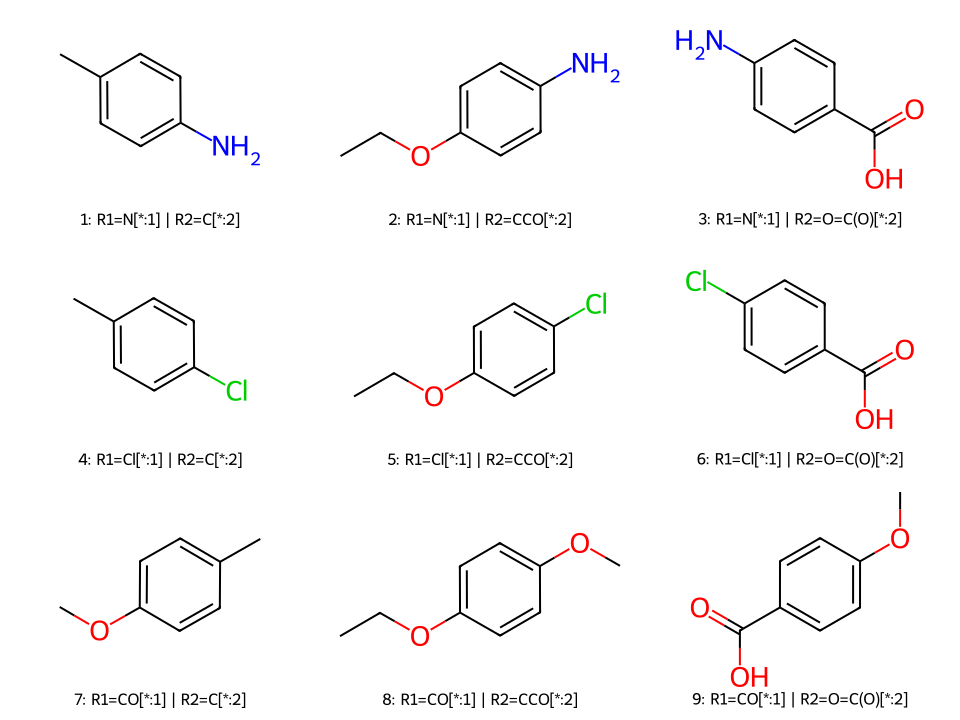

In [13]:
enumerated_records, rgroup_pools = enumerate_rgroup_combinations(rgroup_rows)
product_df = pd.DataFrame([
    {key: value for key, value in record.items() if key != "Mol"}
    for record in enumerated_records
])

print("各位点侧链数:", {label: len(pool) for label, pool in rgroup_pools.items()})
print("去重后产物数:", len(enumerated_records))
display(product_df)

enumerated_mols = [record["Mol"] for record in enumerated_records]
enumerated_labels = list(rgroup_pools)
legends = [
    f"{i + 1}: " + " | ".join(f"{label}={record[label]}" for label in enumerated_labels)
    for i, record in enumerate(enumerated_records)
]

# 可视化结果
grid_options = rdMolDraw2D.MolDrawOptions()
grid_options.addAtomIndices = False
grid_options.addBondIndices = False
Draw.MolsToGridImage(
    enumerated_mols,
    molsPerRow=3,
    subImgSize=(320, 240),
    legends=legends,
    drawOptions=grid_options,
)

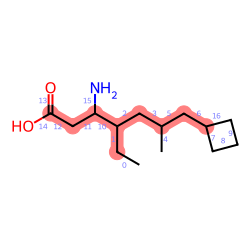

In [14]:
# 找到最长的、可旋转的链（sp3杂化）
from rdkit.Chem.Lipinski import RotatableBondSmarts 
mol = Chem.MolFromSmiles('CCC(CC(C)CC1CCC1)C(CC(=O)O)N')

def find_bond_groups(mol):
    # 一下子得到所有可旋转的键
    rot_atom_pairs = mol.GetSubstructMatches(RotatableBondSmarts) 
    rot_bond_set = set([mol.GetBondBetweenAtoms(*ap).GetIdx() for ap in rot_atom_pairs])

    # 图连通分量的查找（DFS）
    rot_bond_groups = []
    while (rot_bond_set):
        i = rot_bond_set.pop()
        connected_bond_set = set([i])
        stack = [i]
        while (stack):
            i = stack.pop()
            b = mol.GetBondWithIdx(i)
            bonds = []
            for a in (b.GetBeginAtom(), b.GetEndAtom()):
                bonds.extend([b.GetIdx() for b in a.GetBonds() if (
                    (b.GetIdx() in rot_bond_set) and (not (b.GetIdx() in connected_bond_set)))])
            connected_bond_set.update(bonds)
            stack.extend(bonds)
        rot_bond_set.difference_update(connected_bond_set)
        rot_bond_groups.append(tuple(connected_bond_set))
    return tuple(sorted(rot_bond_groups, reverse = True, key = lambda x: len(x))) #所有连通组按照大小排序

bond_groups = find_bond_groups(mol)
largest_n_cont_rot_bonds = len(bond_groups[0]) if bond_groups else 0
mol

In [ ]:
# wiener指数：分子图中所有原子对之间最短路径距离的总和
def wiener_index(m):
    res = 0
    amat = Chem.GetDistanceMatrix(m) # 分子的距离矩阵，amat[i][j]是原子i和原子j之间最短路径的化学边数量
    num_atoms = m.GetNumAtoms()
    for i in range(num_atoms):
        for j in range(i+1,num_atoms):
            res += amat[i][j]
    return res

butane = Chem.MolFromSmiles('CCCC')
print(wiener_index(butane))
isobutane = Chem.MolFromSmiles('CC(C)C')
print(wiener_index(isobutane))

# 简单点不用遍历
def wiener_index2(m):
    res = 0
    amat = Chem.GetDistanceMatrix(m) # 分子的距离矩阵，amat[i][j]是原子i和原子j之间最短路径的化学边数量
    return 0.5 * amat.sum()
print(wiener_index2(butane))
print(wiener_index2(isobutane))

10.0
9.0
10.0
9.0
